In [1]:
import sys
sys.path.append('..')
import subjects
import os
from glob import glob
from tqdm.notebook import trange, tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
import umap
import fast_hdbscan


In [3]:
def cluster_lfp_embeddings(
    embeddings,
    subjects,
    genotypes,
    sessions,
    l2_normalize=True,
    standardize=False,
    cluster_on_umap=False,
    make_umap=True,
    umap_n_neighbors=50,
    umap_min_dist=0.05,
    umap_metric="cosine",
    umap_random_state=0,
    hdbscan_min_cluster_size=50,
    hdbscan_min_samples=10,
    hdbscan_metric="euclidean",
):
    """
    Cluster CNN/contrastive embeddings from LFP events.

    Parameters
    ----------
    embeddings : array, shape (N, D)
        Event embeddings, e.g. (N, 64).
    subjects, genotypes, sessions : array-like, length N
        Metadata for each event.
    l2_normalize : bool
        Whether to L2-normalize embeddings before analysis.
    standardize : bool
        Whether to z-score each embedding dimension.
        Usually False if using L2-normalized contrastive embeddings.
    cluster_on_umap : bool
        If True, cluster on 2D UMAP coordinates.
        If False, cluster directly on embedding space.
    make_umap : bool
        Whether to compute UMAP coordinates for visualization.
    """

    Z = np.asarray(embeddings)

    if standardize:
        Z = StandardScaler().fit_transform(Z)

    if l2_normalize:
        Z = normalize(Z, norm="l2", axis=1)

    # UMAP is useful for visualization, and optionally for clustering
    if make_umap or cluster_on_umap:
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=umap_n_neighbors,
            min_dist=umap_min_dist,
            metric=umap_metric,
            verbose=True
            #random_state=umap_random_state,
        )
        U = reducer.fit_transform(Z)
    else:
        U = None

    cluster_input = U if cluster_on_umap else Z

    clusterer = fast_hdbscan.HDBSCAN(
        min_cluster_size=hdbscan_min_cluster_size,
        min_samples=hdbscan_min_samples,
        metric=hdbscan_metric,
        #prediction_data=True,
        #verbose=True
    )

    labels = clusterer.fit_predict(cluster_input)

    df = pd.DataFrame({
        "event_idx": np.arange(len(Z)),
        "subject": subjects,
        "genotype": genotypes,
        "session": sessions,
        "cluster": labels,
        "cluster_probability": clusterer.probabilities_,
        #"outlier_score": clusterer.outlier_scores_,
    })

    if U is not None:
        df["umap1"] = U[:, 0]
        df["umap2"] = U[:, 1]

    return df, clusterer, U, Z

In [7]:
def plot_umap_clusters(
    df,
    color_by="cluster",
    alpha=0.7,
    s=8,
    cmap="tab20",
):
    if "umap1" not in df or "umap2" not in df:
        raise ValueError("UMAP coordinates not found in dataframe.")

    plt.figure(figsize=(6, 5))

    vals = df[color_by]

    if pd.api.types.is_numeric_dtype(vals):
        sc = plt.scatter(
            df["umap1"],
            df["umap2"],
            c=vals,
            s=s,
            alpha=alpha,
            cmap=cmap,
        )
        plt.colorbar(sc, label=color_by)
    else:
        for val in sorted(vals.dropna().unique()):
            m = vals == val
            plt.scatter(
                df.loc[m, "umap1"],
                df.loc[m, "umap2"],
                s=s,
                alpha=alpha,
                label=str(val),
            )
        plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title(f"Embedding UMAP colored by {color_by}")
    plt.tight_layout()
    plt.show()

In [13]:
import pynndescent
from sklearn.neighbors import NearestNeighbors
import numpy as np


def subject_neighbor_purity(
    Z,
    subject_ids,
    k=20,
    metric="cosine",
    n_jobs=-1,
):
    """
    Fast vectorized nearest-neighbor subject purity.

    Parameters
    ----------
    Z : array, shape (N, D)
        Embeddings.
    subject_ids : array-like, shape (N,)
        Subject label for each sample.
    k : int
        Number of neighbors.
    metric : str
        Neighbor metric.
    """

    subject_ids = np.asarray(subject_ids)
    
    #nbrs = NearestNeighbors(
    #    n_neighbors=k + 1,
    #    metric=metric,
    #    n_jobs=n_jobs,
    #).fit(Z)

    #idx = nbrs.kneighbors(return_distance=False)

    index = pynndescent.NNDescent(
        Z,
        metric="cosine",
        n_neighbors=20,
        verbose=True
    )
    
    idx, dist = index.neighbor_graph

    # remove self-neighbor
    idx = idx[:, 1:]

    # shape: (N, k)
    neighbor_subjects = subject_ids[idx]

    # broadcasting comparison
    matches = neighbor_subjects == subject_ids[:, None]

    purity = matches.mean()

    # expected chance purity
    _, counts = np.unique(subject_ids, return_counts=True)
    probs = counts / counts.sum()

    chance = np.sum(probs ** 2)

    return purity, chance


In [4]:
all_embeddings = []
all_subjects = []
all_sessions = []
all_genotypes = []

ids = subjects.get_subjects()
for animal_id in ids:
    subject = subjects.load(animal_id)

    for session in ['Sleep1', 'Sleep2']:
        df = pd.read_csv(os.path.join(subject['olm']['directory'], session,'ripple_pred.csv'))
        
        embeddings = np.load(os.path.join(subject['olm']['directory'], session,'ripple_embeddings.npy'))
        embeddings = embeddings[df['event'] == 0]
        n_events = len(embeddings)
        
        all_embeddings.append(embeddings)
        all_subjects.append([animal_id] * n_events)
        all_sessions.append([session] * n_events)
        all_genotypes.append([subject['strain']] * n_events)


In [5]:
all_embeddings = np.concatenate(all_embeddings, axis=0)
all_subjects = np.concatenate(all_subjects)
all_sessions = np.concatenate(all_sessions)
all_genotypes = np.concatenate(all_genotypes)

In [6]:
all_embeddings.shape

(159741, 64)

No manipulations - cluster

In [8]:
df_clusters, clusterer, U, Z_used = cluster_lfp_embeddings(
    embeddings=all_embeddings,
    subjects=all_subjects,
    genotypes=all_genotypes,
    sessions=all_sessions,
    l2_normalize=True,
    standardize=False,
    cluster_on_umap=True,   # safest default
    make_umap=True,
    hdbscan_min_cluster_size=50,
    hdbscan_min_samples=10,
    umap_n_neighbors=15,
    umap_min_dist=0.3,
)

F:\ADUnitAnalysis\py13venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.3, verbose=True)
Sun May 24 18:32:08 2026 Construct fuzzy simplicial set
Sun May 24 18:32:08 2026 Finding Nearest Neighbors
Sun May 24 18:32:08 2026 Building RP forest with 25 trees
Sun May 24 18:32:13 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	Stopping threshold met -- exiting after 3 iterations
Sun May 24 18:32:23 2026 Finished Nearest Neighbor Search
Sun May 24 18:32:26 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sun May 24 18:32:48 2026 Finished embedding


In [12]:
purity, chance = subject_neighbor_purity(Z_used, all_subjects)

print("Neighbor subject purity:", purity)
print("Expected chance purity:", chance)

Neighbor subject purity: 0.11685659582501806
Expected chance purity: 0.0383251468861228


Center embeddings by subject

In [14]:
def subject_center_embeddings(Z, subject_ids):
    Zc = Z.copy()
    subject_ids = np.asarray(subject_ids)

    for s in np.unique(subject_ids):
        m = subject_ids == s
        Zc[m] -= Zc[m].mean(axis=0)

    return Zc

Z_subject_centered = subject_center_embeddings(Z_used, all_subjects)

In [15]:
df_clusters_centered, clusterer, U, Z_used_centered = cluster_lfp_embeddings(
    embeddings=all_embeddings,
    subjects=all_subjects,
    genotypes=all_genotypes,
    sessions=all_sessions,
    l2_normalize=True,
    standardize=False,
    cluster_on_umap=True,   # safest default
    make_umap=True,
    hdbscan_min_cluster_size=50,
    hdbscan_min_samples=10,
    umap_n_neighbors=15,
    umap_min_dist=0.3,
)

F:\ADUnitAnalysis\py13venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.3, verbose=True)
Sun May 24 18:35:19 2026 Construct fuzzy simplicial set
Sun May 24 18:35:19 2026 Finding Nearest Neighbors
Sun May 24 18:35:19 2026 Building RP forest with 25 trees
Sun May 24 18:35:19 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	Stopping threshold met -- exiting after 3 iterations
Sun May 24 18:35:22 2026 Finished Nearest Neighbor Search
Sun May 24 18:35:22 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sun May 24 18:35:43 2026 Finished embedding


In [17]:
purity, chance = subject_neighbor_purity(Z_subject_centered, all_subjects)

print("Neighbor subject purity:", purity)
print("Expected chance purity:", chance)

Sun May 24 18:36:07 2026 Building RP forest with 25 trees
Sun May 24 18:36:08 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	Stopping threshold met -- exiting after 3 iterations
Neighbor subject purity: 0.19551682180266147
Expected chance purity: 0.0383251468861228


In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

clf = LogisticRegression(max_iter=1000)

scores = cross_val_score(
    clf,
    all_embeddings,
    all_genotypes,
    cv=5,
)

print(scores.mean())

0.5345151076765982


In [62]:
purity, chance = subject_neighbor_purity(all_embeddings, all_subjects)

print("Neighbor subject purity:", purity)
print("Expected chance purity:", chance)

Neighbor subject purity: 0.11545157473660485
Expected chance purity: 0.038325146886122805


In [83]:
purity, chance = subject_neighbor_purity(Z_subject_centered, all_subjects)

print("Neighbor subject purity:", purity)
print("Expected chance purity:", chance)

Neighbor subject purity: 0.1837446241102785
Expected chance purity: 0.0383251468861228


In [60]:
pd.crosstab(df_clusters["cluster"], df_clusters["subject"], normalize="index")

subject,106-2,18-1,229-3,233-10,236-1,236-20,243-1,243-10,244-2,245-10,...,62-1,64-30,65-1,65-2,70-1,70-10,84-10,86-2,86-3,87-21
cluster,,,,,,,,,,,,,,,,,,,,,
-1,0.022897,0.017834,0.023558,0.018054,0.024439,0.011889,0.014971,0.014751,0.048437,0.026640,...,0.009027,0.056803,0.032585,0.015852,0.052840,0.049978,0.028181,0.026200,0.024218,0.052400
0,0.050251,0.050251,0.030151,0.005025,0.080402,0.000000,0.020101,0.040201,0.050251,0.055276,...,0.005025,0.005025,0.005025,0.015075,0.000000,0.015075,0.025126,0.020101,0.025126,0.015075
1,0.000000,0.066667,0.066667,0.050000,0.000000,0.000000,0.016667,0.000000,0.000000,0.016667,...,0.016667,0.000000,0.000000,0.050000,0.050000,0.033333,0.000000,0.000000,0.033333,0.183333
2,0.000000,0.013514,0.013514,0.000000,0.000000,0.013514,0.000000,0.000000,0.040541,0.000000,...,0.000000,0.108108,0.391892,0.000000,0.081081,0.013514,0.054054,0.000000,0.094595,0.054054
3,0.034475,0.043102,0.021470,0.025338,0.043341,0.011810,0.024563,0.026920,0.033610,0.023194,...,0.009905,0.037942,0.013263,0.037710,0.050398,0.057818,0.031253,0.025700,0.054621,0.039111


In [63]:
def subject_center_embeddings(Z, subject_ids):
    Zc = Z.copy()
    subject_ids = np.asarray(subject_ids)

    for s in np.unique(subject_ids):
        m = subject_ids == s
        Zc[m] -= Zc[m].mean(axis=0)

    return Zc

Z_subject_centered = subject_center_embeddings(all_embeddings, all_subjects)

In [64]:
Z_subject_centered.shape

(159741, 64)

In [71]:
df_clusters, clusterer, U, Z_used = cluster_lfp_embeddings(
    embeddings=all_embeddings,
    subjects=all_subjects,
    genotypes=all_genotypes,
    sessions=all_sessions,
    l2_normalize=True,
    standardize=False,
    cluster_on_umap=True,   # safest default
    make_umap=True,
    hdbscan_min_cluster_size=50,
    hdbscan_min_samples=10,
    umap_n_neighbors=15,
    umap_min_dist=0.3,
)

F:\ADUnitAnalysis\py13venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.3, verbose=True)
Sun May 24 18:20:26 2026 Construct fuzzy simplicial set
Sun May 24 18:20:26 2026 Finding Nearest Neighbors
Sun May 24 18:20:26 2026 Building RP forest with 25 trees
Sun May 24 18:20:26 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	Stopping threshold met -- exiting after 3 iterations
Sun May 24 18:20:29 2026 Finished Nearest Neighbor Search
Sun May 24 18:20:29 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sun May 24 18:20:50 2026 Finished embedding


In [72]:
df_clusters_centered, clusterer, U, Z_used = cluster_lfp_embeddings(
    embeddings=Z_subject_centered,
    subjects=all_subjects,
    genotypes=all_genotypes,
    sessions=all_sessions,
    l2_normalize=True,
    standardize=False,
    cluster_on_umap=True,   # safest default
    make_umap=True,
    hdbscan_min_cluster_size=50,
    hdbscan_min_samples=10,
    umap_n_neighbors=15,
    umap_min_dist=0.3,
)

F:\ADUnitAnalysis\py13venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.3, verbose=True)
Sun May 24 18:20:51 2026 Construct fuzzy simplicial set
Sun May 24 18:20:51 2026 Finding Nearest Neighbors
Sun May 24 18:20:51 2026 Building RP forest with 25 trees
Sun May 24 18:20:52 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	Stopping threshold met -- exiting after 3 iterations
Sun May 24 18:20:54 2026 Finished Nearest Neighbor Search
Sun May 24 18:20:55 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sun May 24 18:21:16 2026 Finished embedding


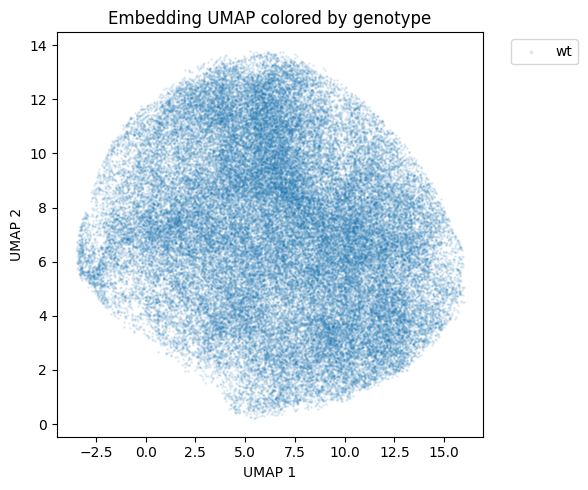

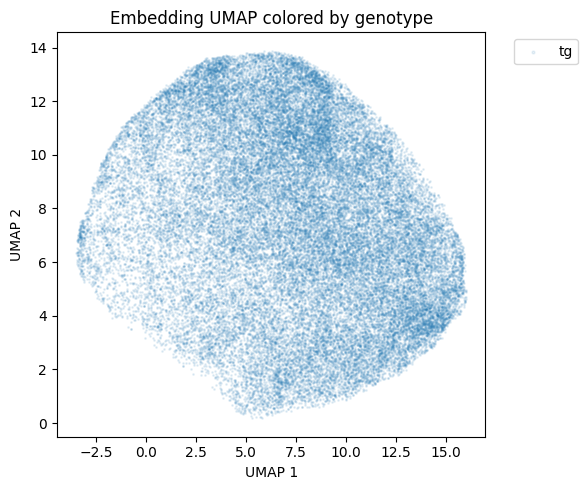

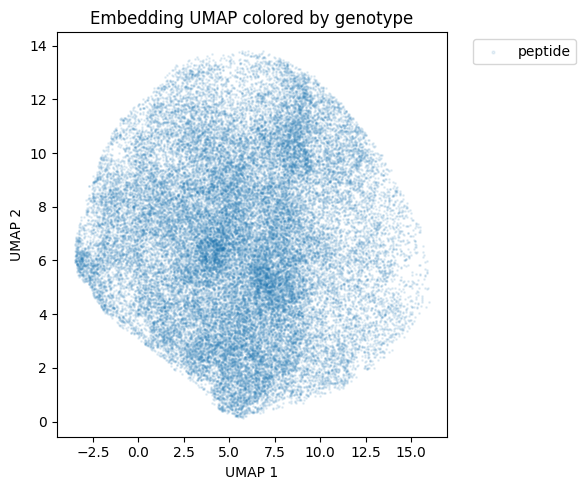

In [80]:
plot_umap_clusters(df_clusters[df_clusters['genotype'] == 'wt'], color_by='genotype', s=1, alpha=0.1)
plot_umap_clusters(df_clusters[df_clusters['genotype'] == 'tg'], color_by='genotype', s=1, alpha=0.1)
plot_umap_clusters(df_clusters[df_clusters['genotype'] == 'peptide'], color_by='genotype', s=1, alpha=0.1)


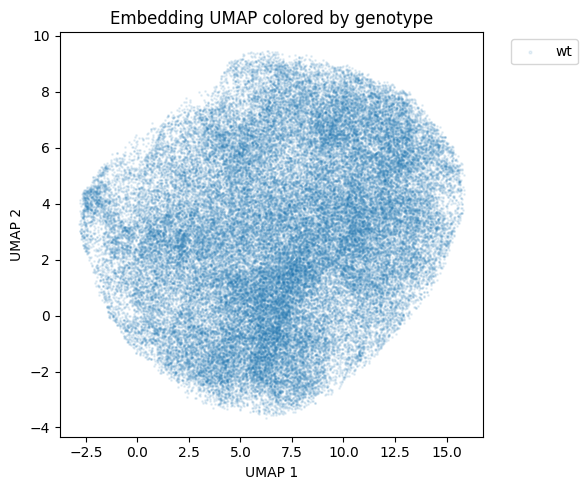

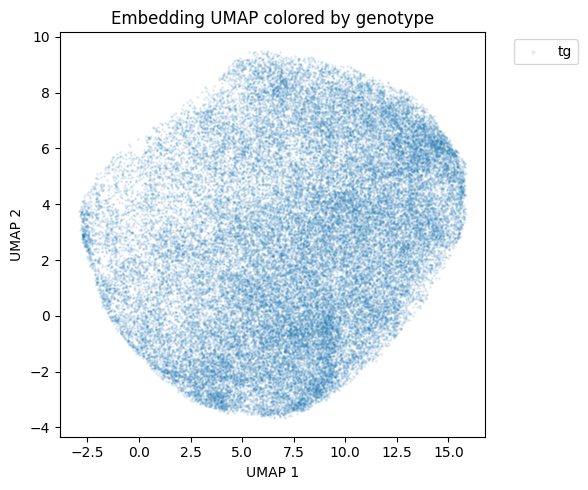

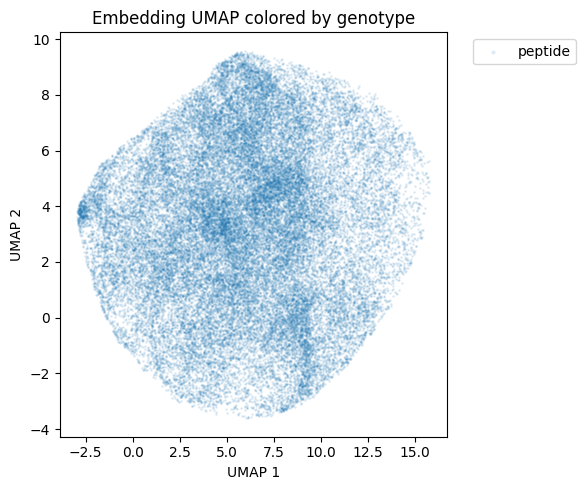

In [81]:
plot_umap_clusters(df_clusters_centered[df_clusters_centered['genotype'] == 'wt'], color_by='genotype', s=1, alpha=0.1)
plot_umap_clusters(df_clusters_centered[df_clusters_centered['genotype'] == 'tg'], color_by='genotype', s=1, alpha=0.1)
plot_umap_clusters(df_clusters_centered[df_clusters_centered['genotype'] == 'peptide'], color_by='genotype', s=1, alpha=0.1)


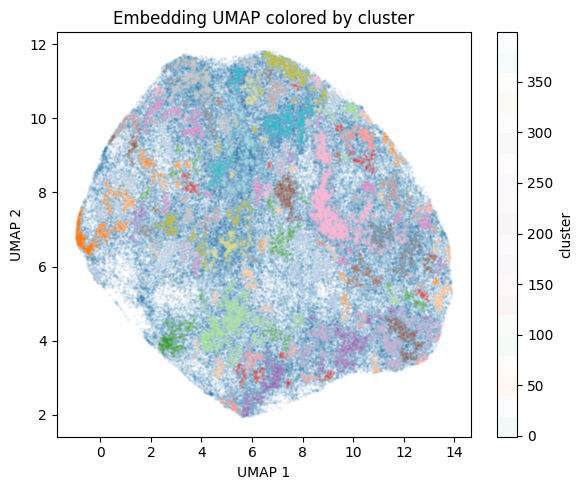

In [30]:
plot_umap_clusters(df_clusters, color_by="cluster", s=1, alpha=0.05)


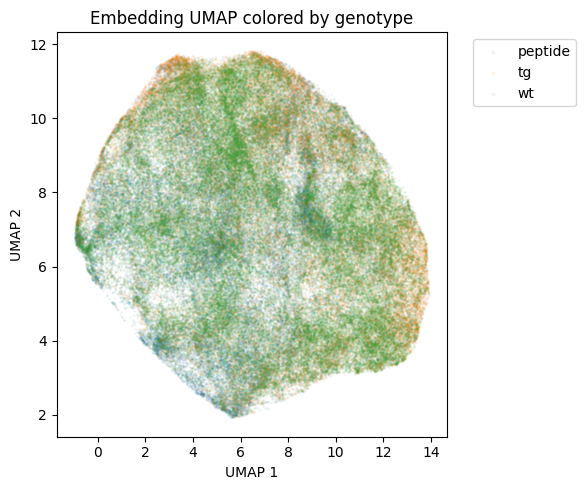

In [31]:
plot_umap_clusters(df_clusters, color_by="genotype", s=1, alpha=0.05)


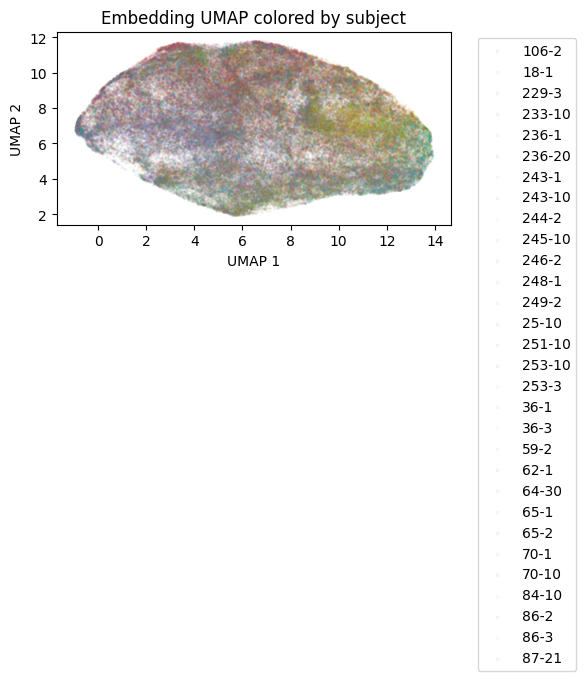

In [40]:
plot_umap_clusters(df_clusters, color_by="subject", s=1, alpha=0.05)


In [ ]:
plot_umap_clusters(df_clusters, color_by="cluster")
plot_umap_clusters(df_clusters, color_by="genotype")
plot_umap_clusters(df_clusters, color_by="subject")
plot_umap_clusters(df_clusters, color_by="session")